In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Dataset, random_split
import random

from IPython.display import display

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
torch.set_default_device(DEVICE)

Using device: cuda


In [3]:
data = pd.read_csv('ranking_dataset.csv')
data.describe()
X = data
display(X.describe())
display(X.head())

,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,500.537200,506.623500,501.396300,501.42390,493.817300,495.837500,501.616300,505.314100,500.361700,500.02570,4.508600,4.546900,4.49630,4.511000,4.444500,4.443100,4.506400,4.544000,4.498000,4.501200
std,290.444477,289.410167,288.372805,289.29438,289.255414,290.777883,288.663129,288.731189,288.747163,290.38134,2.876031,2.888639,2.86056,2.866409,2.884086,2.878297,2.857022,2.867523,2.861261,2.882365
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,248.000000,255.750000,256.000000,251.00000,244.000000,240.000000,250.750000,257.000000,249.000000,248.00000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,500.000000,511.000000,500.000000,505.00000,489.000000,496.000000,504.000000,504.000000,501.500000,501.00000,5.000000,5.000000,4.00000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000
75%,755.000000,757.000000,752.250000,754.25000,745.000000,746.000000,753.250000,757.000000,752.000000,754.00000,7.000000,7.000000,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
max,999.000000,999.000000,999.000000,999.00000,999.000000,999.000000,999.000000,999.000000,999.000000,999.00000,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
0,542,67,876,414,26,335,620,924,950,113,5,1,7,4,0,3,6,8,9,2
1,378,14,210,954,231,572,315,295,567,706,5,0,1,9,2,7,4,3,6,8
2,749,876,73,111,899,213,541,769,287,219,6,8,0,1,9,2,5,7,4,3
3,372,880,475,329,733,564,739,376,632,10,2,9,4,1,7,5,8,3,6,0
4,186,822,577,519,707,123,143,294,693,677,2,9,5,4,8,0,1,3,7,6


In [4]:
class RankingDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X.values, dtype=torch.float32).to(DEVICE)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Add a sequence dimension for RNN input
        d = self.X[idx].unsqueeze(-1)
        return torch.cat([d[:10], torch.tensor([[-1]]), d[10:]], dim=0)  # Use a token (-1) to separate input and target

dataset = RankingDataset(X)
train_dataloader, test_dataloader, valid_dataloader = [
    DataLoader(x, batch_size=32, shuffle=True, generator=torch.Generator(device=DEVICE))
    for x in
    random_split(dataset, [0.6, 0.2, 0.2], generator=torch.Generator(device=DEVICE))
]

In [5]:
class RNN(torch.nn.Module):
    def __init__(self):
        """Initialize a module with the following architecture:
        - RNN layer with input size 1 and hidden size 128, with 5 layers and batch_first=True
        - ReLU activation
        - Linear layer with input size 128 and output size 10
        """
        super().__init__()
        self.rnn = torch.nn.RNN(input_size=1, hidden_size=128, batch_first=True, num_layers=5)
        self.linear = torch.nn.Linear(128, 10)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        # print(x.shape)
        rnn_out, hidden = self.rnn(x)
        # print(rnn_out.shape)
        # print(hidden[-1].shape)
        output = self.linear(self.relu(hidden[-1]))
        # print(output.shape)
        return output

model = RNN().to(DEVICE)
print(model)

RNN(
  (rnn): RNN(1, 128, num_layers=5, batch_first=True)
  (linear): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [6]:
def train(model, train_dataloader, valid_dataloader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.MSELoss()

    losses = []
    valid_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch in train_dataloader:
            X_batch = X_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            y_batch = X_batch[:, -10:, -1]  # The last 10 columns represent the target ranking
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(train_dataloader))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[-1]:.4f}")

        model.eval()
        with torch.no_grad():
            valid_loss = 0
            for X_batch in valid_dataloader:
                X_batch = X_batch.to(DEVICE)
                y_batch = X_batch[:, -10:, -1]  # The last 10 columns represent the target ranking
                X_batch = X_batch[:, :11, :]  # Use only the first 11 columns as input
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                valid_loss += loss.item()
        valid_losses.append(valid_loss / len(valid_dataloader))
        print(f"Validation Loss: {valid_losses[-1]:.4f}")

    return losses, valid_losses

Epoch 1/15, Loss: 10.1899
Validation Loss: 8.2548
Epoch 2/15, Loss: 8.2566
Validation Loss: 8.2591
Epoch 3/15, Loss: 8.2613
Validation Loss: 8.2670
Epoch 4/15, Loss: 8.2633
Validation Loss: 8.2552
Epoch 5/15, Loss: 8.2621
Validation Loss: 8.2618
Epoch 6/15, Loss: 8.2605
Validation Loss: 8.2733
Epoch 7/15, Loss: 8.2666
Validation Loss: 8.2627
Epoch 8/15, Loss: 8.2665
Validation Loss: 8.2582
Epoch 9/15, Loss: 8.2645
Validation Loss: 8.2653
Epoch 10/15, Loss: 8.2680
Validation Loss: 8.2508
Epoch 11/15, Loss: 8.2693
Validation Loss: 8.2532
Epoch 12/15, Loss: 8.2653
Validation Loss: 8.2702
Epoch 13/15, Loss: 8.2649
Validation Loss: 8.2720
Epoch 14/15, Loss: 8.2674
Validation Loss: 8.2945
Epoch 15/15, Loss: 8.2647
Validation Loss: 8.2567


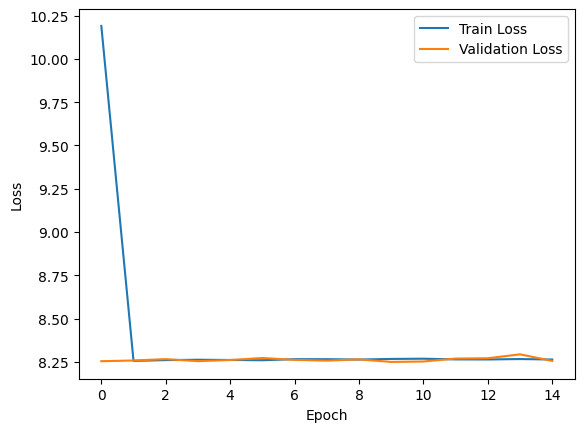

In [7]:
train_losses, valid_losses = train(model, train_dataloader, valid_dataloader, epochs=15)
torch.save(model.state_dict(), 'models/rnn.pth')
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [8]:
# Test the model on the test set
model.eval()
with torch.no_grad():
    test_loss = 0
    for X_batch in test_dataloader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch[:, :11, :])  # Use only the first 11 columns as input
        loss = torch.nn.MSELoss()(outputs, X_batch[:, -10:, -1])  # The last 10 columns represent the target ranking
        test_loss += loss.item()
print(f"Test Loss: {test_loss / len(test_dataloader):.4f}")

Test Loss: 8.2561


In [9]:
# Let's see the model's predictions on some test data
model.eval()
i = random.randint(0, len(test_dataloader.dataset) - 1)
sample_input = (
    torch.tensor(X.iloc[i, :10].values, dtype=torch.float32).unsqueeze(0).to(DEVICE).unsqueeze(-1)
)
with torch.no_grad():
    predicted_ranking = model(sample_input).squeeze(0).cpu().numpy()
x = np.concatenate([X.iloc[i, :10].to_numpy(), [-1]])  # Add the token used to separate input and target
y_true = X.iloc[i, -10:].to_numpy()  # The last 10 columns represent the target ranking

print(f"Input:                             {x}")
print(f"Predicted Ranking:                 {predicted_ranking}")
print(f"True Ranking:                      {y_true}")
print(f"Predicted (argsorted):             {np.argsort(np.argsort(predicted_ranking))}")
print(f"True order:                        {x[np.argsort(y_true)]}")
print(f"Input sorted by predicted ranking: {x[np.argsort(predicted_ranking)]}")

Input:                             [ 54 922 277 396 510 476 563 929 691 272  -1]
Predicted Ranking:                 [4.509381  4.6827207 4.534114  4.5997114 4.5432024 4.3195925 4.5014024
 4.4816523 4.463161  4.354558 ]
True Ranking:                      [0 8 2 3 5 4 6 9 7 1]
Predicted (argsorted):             [5 9 6 8 7 0 4 3 2 1]
True order:                        [ 54 272 277 396 476 510 563 691 922 929]
Input sorted by predicted ranking: [476 272 691 929 563  54 277 510 396 922]


In [10]:
accuracies = []
for X_batch in test_dataloader:
    predictions = torch.argsort(torch.argsort(model(X_batch.to(DEVICE)).cpu(), dim=1), dim=1)
    y_batch = X_batch[:, -10:, -1].cpu()  # The last 10 columns represent the target ranking
    accuracies.extend((predictions == y_batch).float().mean(dim=1).tolist())

Average accuracy on test set: 0.1062


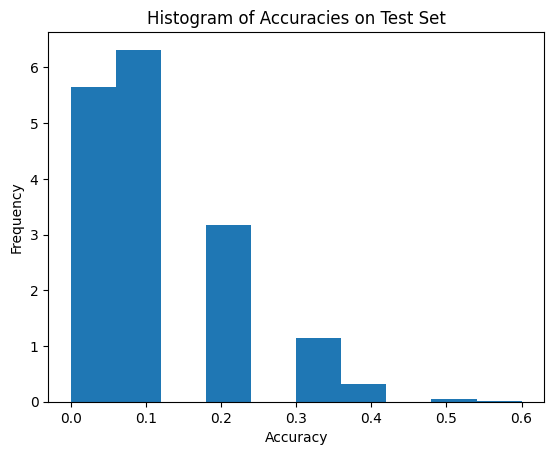

In [11]:
# Plot histogram of accuracies:
print(f"Average accuracy on test set: {sum(accuracies) / len(accuracies):.4f}")
plt.hist(accuracies, bins=10, density=True)
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.title('Histogram of Accuracies on Test Set')
plt.show()

In [12]:
print(f"Percent of arrays it correctly ranked: {sum([1 for acc in accuracies if acc == 1]) / len(accuracies) * 100:.2f}%")

Percent of arrays it correctly ranked: 0.00%


In [13]:
# Let's see the model's predictions on some test data
sample_input = torch.tensor(
    [[[23], [25], [12], [5], [17], [9], [30], [1], [8], [15]]], dtype=torch.float32
).to(DEVICE)
print(f"Sample input shape: {sample_input.shape}")
with torch.no_grad():
    predicted_ranking = model(sample_input).squeeze(0).cpu().numpy()
y_true = np.array([7, 8, 6, 4, 5, 3, 9, 0, 2, 1])  # The true ranking of the input array

print(f"Input:                             {x}")
print(f"Predicted Ranking:                 {predicted_ranking}")
print(f"True Ranking:                      {y_true}")
print(f"Predicted (argsorted):             {np.argsort(np.argsort(predicted_ranking))}")
print(f"True order:                        {x[np.argsort(y_true)]}")
print(f"Input sorted by predicted ranking: {x[np.argsort(predicted_ranking)]}")
print(f"Accuracy:                          {np.mean(np.argsort(np.argsort(predicted_ranking)) == y_true):.4f}")

Sample input shape: torch.Size([1, 10, 1])
Input:                             [ 54 922 277 396 510 476 563 929 691 272  -1]
Predicted Ranking:                 [4.509378  4.682718  4.534113  4.5997095 4.543202  4.3195906 4.5014014
 4.481651  4.463159  4.354555 ]
True Ranking:                      [7 8 6 4 5 3 9 0 2 1]
Predicted (argsorted):             [5 9 6 8 7 0 4 3 2 1]
True order:                        [929 272 691 476 396 510 277  54 922 563]
Input sorted by predicted ranking: [476 272 691 929 563  54 277 510 396 922]
Accuracy:                          0.3000
